# Underwater Image Enhancement — U-Net Training
**Environment:** Google Colab (T4 GPU)  
**Model:** U-Net with EfficientNetB0 pretrained encoder  
**Dataset:** UIEB (890 paired images)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
# This connects Colab to your Google Drive so we can:
# 1. Read the dataset you uploaded there
# 2. Save trained model weights permanently
# Without this, everything is lost when the Colab session ends.

from google.colab import drive
drive.mount('/content/drive')

print("✅ Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive mounted


In [3]:
# ── Clone GitHub Repo ─────────────────────────────────────────────────────────
# This pulls your src/ folder into Colab so we can import
# dataset.py, train.py etc. directly.

import subprocess

GITHUB_URL = "https://github.com/danielakbank/underwater-image-enhancement.git"

result = subprocess.run(
    ["git", "clone", GITHUB_URL, "/content/underwater"],
    capture_output=True,
    text=True
)

print(result.stdout or "✅ Repo cloned successfully")
print(result.stderr if result.returncode != 0 else "")

✅ Repo cloned successfully



In [4]:
# ── Install Dependencies ──────────────────────────────────────────────────────
# Colab already has TensorFlow, NumPy, and OpenCV pre-installed.
# We only install what's missing.

!pip install scikit-image tqdm --quiet

print("✅ Dependencies ready")

✅ Dependencies ready


In [5]:
# ── Verify GPU ────────────────────────────────────────────────────────────────
# IMPORTANT: If this shows ❌, go to:
# Runtime → Change runtime type → Hardware accelerator → T4 GPU
# Then run all cells again from the top.

import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ GPU available: {gpus[0].name}")
    print(f"   TensorFlow: {tf.__version__}")
else:
    print("❌ No GPU — go to Runtime → Change runtime type → T4 GPU")

✅ GPU available: /physical_device:GPU:0
   TensorFlow: 2.20.0


In [13]:
# ── Diagnose ──────────────────────────────────────────────────────────────────
import os

RAW_DIR = "/content/drive/MyDrive/underwater-data/raw"
REF_DIR = "/content/drive/MyDrive/underwater-data/reference"

# Check if folders exist
print(f"raw/ exists : {os.path.exists(RAW_DIR)}")
print(f"ref/ exists : {os.path.exists(REF_DIR)}")

# Check contents
if os.path.exists(RAW_DIR):
    files = os.listdir(RAW_DIR)
    print(f"\nraw/ count  : {len(files)}")
    print(f"First 5     : {files[:5]}")
else:
    print("❌ raw/ not found")

# Check what is actually in underwater-data
print(f"\nContents of underwater-data/:")
base = "/content/drive/MyDrive/underwater-data"
if os.path.exists(base):
    for item in os.listdir(base):
        full = os.path.join(base, item)
        if os.path.isdir(full):
            count = len(os.listdir(full))
            print(f"  📁 {item}/ ({count} files)")
        else:
            print(f"  📄 {item}")
else:
    print("❌ underwater-data not found — checking MyDrive root...")
    root = "/content/drive/MyDrive"
    for item in os.listdir(root):
        print(f"  {item}")

raw/ exists : True
ref/ exists : True

raw/ count  : 890
First 5     : ['10945.png', '10139.png', '111_img_.png', '105_img_.png', '106_img_.png']

Contents of underwater-data/:
  📁 reference/ (890 files)
  📁 raw/ (890 files)


In [12]:
# ── Load Dataset ──────────────────────────────────────────────────────────────
# Reads images from your Google Drive folders.
# Make sure you have uploaded:
#   underwater-data/raw/        (890 degraded images)
#   underwater-data/reference/  (890 reference images)
# to your Google Drive before running this cell.

import sys
sys.path.insert(0, '/content/underwater/src')

from dataset import load_dataset

RAW_DIR = "/content/drive/MyDrive/underwater-data/raw"
REF_DIR = "/content/drive/MyDrive/underwater-data/reference"

print("Loading dataset — this may take 1–2 minutes...")
raw_images, ref_images = load_dataset(RAW_DIR, REF_DIR)

print(f"\n  Raw images shape  : {raw_images.shape}")
print(f"  Ref images shape  : {ref_images.shape}")
print(f"  Memory used       : {raw_images.nbytes / 1e6:.1f} MB")
print("  ✅ Dataset loaded")

Loading dataset — this may take 1–2 minutes...
  ✅  Found 890 matched image pairs


Loading images: 100%|██████████| 890/890 [14:44<00:00,  1.01it/s]



  Raw images shape  : (890, 256, 256, 3)
  Ref images shape  : (890, 256, 256, 3)
  Memory used       : 699.9 MB
  ✅ Dataset loaded


In [16]:
# ── Build Model and Data Pipelines ────────────────────────────────────────────

import numpy as np
from train import build_model, build_dataset, build_callbacks, CONFIG

# ── Debug: check what came out of Cell 6 ──
print(f"  Total images loaded : {len(raw_images)}")
print(f"  Val split ratio     : {CONFIG['val_split']}")

# ── Train / Validation split ──
val_size = int(len(raw_images) * CONFIG["val_split"])
print(f"  Val size calculated : {val_size}")

# Shuffle before splitting so validation isn't just the first N images
indices = np.random.permutation(len(raw_images))
raw_shuffled = raw_images[indices]
ref_shuffled = ref_images[indices]

val_raw   = raw_shuffled[:val_size]
val_ref   = ref_shuffled[:val_size]
train_raw = raw_shuffled[val_size:]
train_ref = ref_shuffled[val_size:]

print(f"\n  Training pairs   : {len(train_raw)}")
print(f"  Validation pairs : {len(val_raw)}")

# Safety check before building pipelines
assert len(train_raw) > 0, "❌ Training set is empty — check dataset loaded correctly in Cell 6"
assert len(val_raw) > 0,   "❌ Validation set is empty — check val_split in CONFIG"

# ── tf.data pipelines ──
# Fixed augmentation — operates on individual images not stacked pairs
def augment_pair(raw, ref):
    """Apply identical random flip to both images in a pair."""
    seed = tf.random.uniform(shape=(), maxval=2, dtype=tf.int32)
    raw = tf.cond(seed > 0,
                  lambda: tf.image.flip_left_right(raw),
                  lambda: raw)
    ref = tf.cond(seed > 0,
                  lambda: tf.image.flip_left_right(ref),
                  lambda: ref)
    return raw, ref

# Build datasets manually here to use the fixed augmentation
import tensorflow as tf

train_ds = tf.data.Dataset.from_tensor_slices((train_raw, train_ref))
train_ds = train_ds.map(augment_pair, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(len(train_raw)).batch(CONFIG["batch_size"]).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((val_raw, val_ref))
val_ds = val_ds.batch(CONFIG["batch_size"]).prefetch(tf.data.AUTOTUNE)

# ── Build model ──
model = build_model(input_shape=(256, 256, 3))

print(f"\n  Total parameters : {model.count_params():,}")
print("  ✅ Model ready for training")

  Total images loaded : 890
  Val split ratio     : 0.15
  Val size calculated : 133

  Training pairs   : 757
  Validation pairs : 133

  Total parameters : 10,115,414
  ✅ Model ready for training


In [18]:
# ── Train ─────────────────────────────────────────────────────────────────────
from train import combined_loss, CONFIG

import os
import time
import tensorflow as tf
from tensorflow import keras

MODEL_SAVE_PATH = "/content/drive/MyDrive/underwater-data/unet_efficientnetb0.keras"
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

# ── Shared Callbacks ──────────────────────────────────────────────────────────
# These run across both phases

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=MODEL_SAVE_PATH,
    monitor="val_loss",
    save_best_only=True,     # only saves when val_loss improves
    verbose=1,
)

early_stop_cb = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,             # stop if no improvement for 10 epochs
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,              # halve the learning rate
    patience=5,              # after 5 epochs of no improvement
    min_lr=1e-7,
    verbose=1,
)

# Logs epoch time so you can estimate total training duration
class EpochTimer(keras.callbacks.Callback):
    def on_epoch_begin(self, epoch, logs=None):
        self._start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        elapsed = time.time() - self._start
        print(f"   ⏱  Epoch time: {elapsed:.1f}s")

timer_cb = EpochTimer()

# ── Phase 1: Train Decoder Only ───────────────────────────────────────────────
# Encoder weights are frozen — only the decoder learns.
# This is faster and prevents the pretrained encoder from being
# destabilised before the decoder has learned the task.

print("=" * 60)
print("PHASE 1 — Decoder training (encoder frozen)")
print(f"Epochs: 20  |  LR: {CONFIG['learning_rate']}")
print("=" * 60)

# Confirm encoder is frozen
model.layers[1].trainable = False  # EfficientNetB0 is layer index 1

model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["learning_rate"]
    ),
    loss=combined_loss,
    metrics=["mae"],
)

phase1_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_cb, early_stop_cb, reduce_lr_cb, timer_cb],
    verbose=1,
)

print(f"\n✅ Phase 1 complete")
print(f"   Best val_loss : {min(phase1_history.history['val_loss']):.4f}")

# ── Phase 2: Fine-tune Full Network ──────────────────────────────────────────
# Unfreeze the encoder and train end-to-end.
# Use a much smaller learning rate (10x smaller) so the pretrained
# encoder weights are adjusted gently — not overwritten.
# Gradient clipping prevents large destabilising weight updates.

print("\n" + "=" * 60)
print("PHASE 2 — Full fine-tuning (encoder unfrozen)")
print(f"Epochs: 30  |  LR: {CONFIG['learning_rate'] / 10}")
print("=" * 60)

# Unfreeze the full model
model.layers[1].trainable = True

# Recompile with lower learning rate and gradient clipping
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=CONFIG["learning_rate"] / 10,  # 10x smaller
        clipnorm=1.0,   # clip gradients to prevent instability
    ),
    loss=combined_loss,
    metrics=["mae"],
)

# Reset early stopping patience for phase 2
early_stop_phase2 = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_phase2 = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-8,     # lower floor for fine-tuning
    verbose=1,
)

phase2_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=30,
    callbacks=[checkpoint_cb, early_stop_phase2, reduce_lr_phase2, timer_cb],
    verbose=1,
)

print(f"\n✅ Phase 2 complete")
print(f"   Best val_loss : {min(phase2_history.history['val_loss']):.4f}")

# ── Training Summary ──────────────────────────────────────────────────────────

all_val_loss = (
    phase1_history.history["val_loss"] +
    phase2_history.history["val_loss"]
)
all_val_mae = (
    phase1_history.history["val_mae"] +
    phase2_history.history["val_mae"]
)

total_epochs = len(all_val_loss)
best_loss    = min(all_val_loss)
best_mae     = min(all_val_mae)
best_epoch   = all_val_loss.index(best_loss) + 1

print("\n" + "=" * 60)
print("TRAINING SUMMARY")
print("=" * 60)
print(f"  Total epochs trained : {total_epochs}")
print(f"  Best val loss        : {best_loss:.4f}  (epoch {best_epoch})")
print(f"  Best val MAE         : {best_mae:.4f}")
print(f"  Model saved to       : {MODEL_SAVE_PATH}")
print("=" * 60)

PHASE 1 — Decoder training (encoder frozen)
Epochs: 20  |  LR: 0.0001
Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - loss: 0.4087 - mae: 0.2006
Epoch 1: val_loss improved from None to 0.44337, saving model to /content/drive/MyDrive/underwater-data/unet_efficientnetb0.keras

Epoch 1: finished saving model to /content/drive/MyDrive/underwater-data/unet_efficientnetb0.keras
   ⏱  Epoch time: 104.7s
95/95 ━━━━━━━━━━━━━━━━━━━━ 105s 706ms/step - loss: 0.3425 - mae: 0.1790 - val_loss: 0.4434 - val_mae: 0.2117 - learning_rate: 1.0000e-04
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - loss: 0.2382 - mae: 0.1424
Epoch 2: val_loss improved from 0.44337 to 0.41807, saving model to /content/drive/MyDrive/underwater-data/unet_efficientnetb0.keras

Epoch 2: finished saving model to /content/drive/MyDrive/underwater-data/unet_efficientnetb0.keras
   ⏱  Epoch time: 67.6s
95/95 ━━━━━━━━━━━━━━━━━━━━ 68s 134ms/step - loss: 0.2264 - mae: 0.1375 - val_loss: 0.4181 - val_mae: 0.1983 - learning_

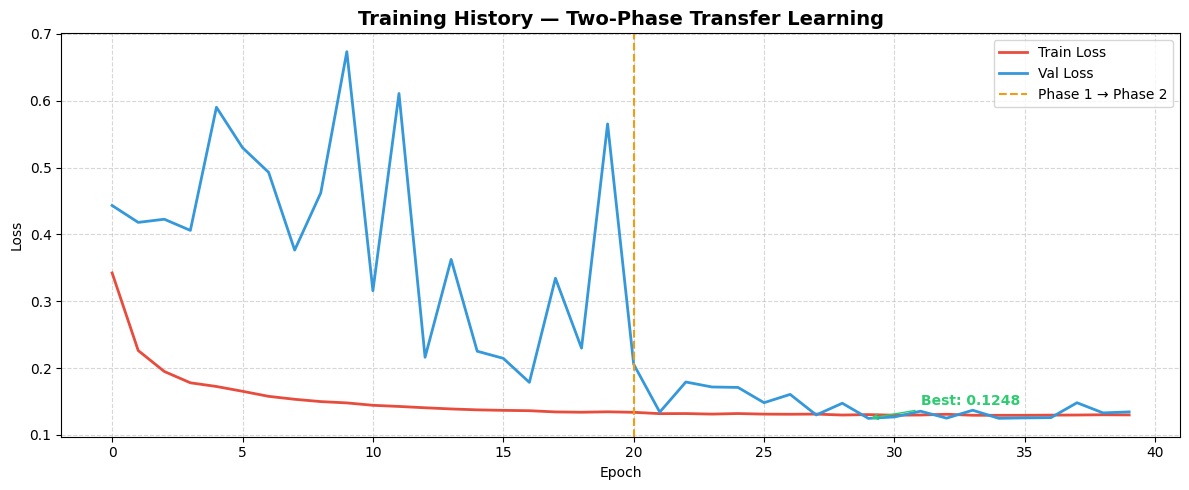

✅ Training history saved


In [19]:
# ── Training History ──────────────────────────────────────────────────────────

import matplotlib.pyplot as plt
import numpy as np

# Combine both phase histories
train_loss = (
    phase1_history.history["loss"] +
    phase2_history.history["loss"]
)
val_loss = (
    phase1_history.history["val_loss"] +
    phase2_history.history["val_loss"]
)

phase1_len = len(phase1_history.history["loss"])
total_len  = len(train_loss)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(train_loss, label="Train Loss", color="#e74c3c", linewidth=2)
ax.plot(val_loss,   label="Val Loss",   color="#3498db", linewidth=2)

# Mark the phase boundary
ax.axvline(
    x=phase1_len,
    color="#f39c12",
    linestyle="--",
    linewidth=1.5,
    label="Phase 1 → Phase 2"
)

# Annotate best epoch
best_epoch = int(np.argmin(val_loss))
best_val   = min(val_loss)
ax.annotate(
    f"Best: {best_val:.4f}",
    xy=(best_epoch, best_val),
    xytext=(best_epoch + 2, best_val + 0.02),
    fontsize=10,
    color="#2ecc71",
    fontweight="bold",
    arrowprops=dict(arrowstyle="->", color="#2ecc71"),
)

ax.set_title("Training History — Two-Phase Transfer Learning",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()

PLOT_PATH = "/content/drive/MyDrive/underwater-data/training_history.png"
plt.savefig(PLOT_PATH, dpi=150, bbox_inches="tight")
plt.show()

print(f"✅ Training history saved")

Running inference on validation samples...

  Sample 1:
    Baseline  — PSNR: 16.47 dB  | SSIM: 0.8721
    CNN       — PSNR: 20.01 dB  | SSIM: 0.8096
    Improvement — PSNR: +3.54 dB | SSIM: -0.0625

  Sample 2:
    Baseline  — PSNR: 16.38 dB  | SSIM: 0.7534
    CNN       — PSNR: 23.06 dB  | SSIM: 0.8939
    Improvement — PSNR: +6.68 dB | SSIM: +0.1404

  Sample 3:
    Baseline  — PSNR: 16.16 dB  | SSIM: 0.6882
    CNN       — PSNR: 18.34 dB  | SSIM: 0.8148
    Improvement — PSNR: +2.19 dB | SSIM: +0.1265

  Sample 4:
    Baseline  — PSNR: 11.87 dB  | SSIM: 0.6544
    CNN       — PSNR: 19.21 dB  | SSIM: 0.7760
    Improvement — PSNR: +7.34 dB | SSIM: +0.1217



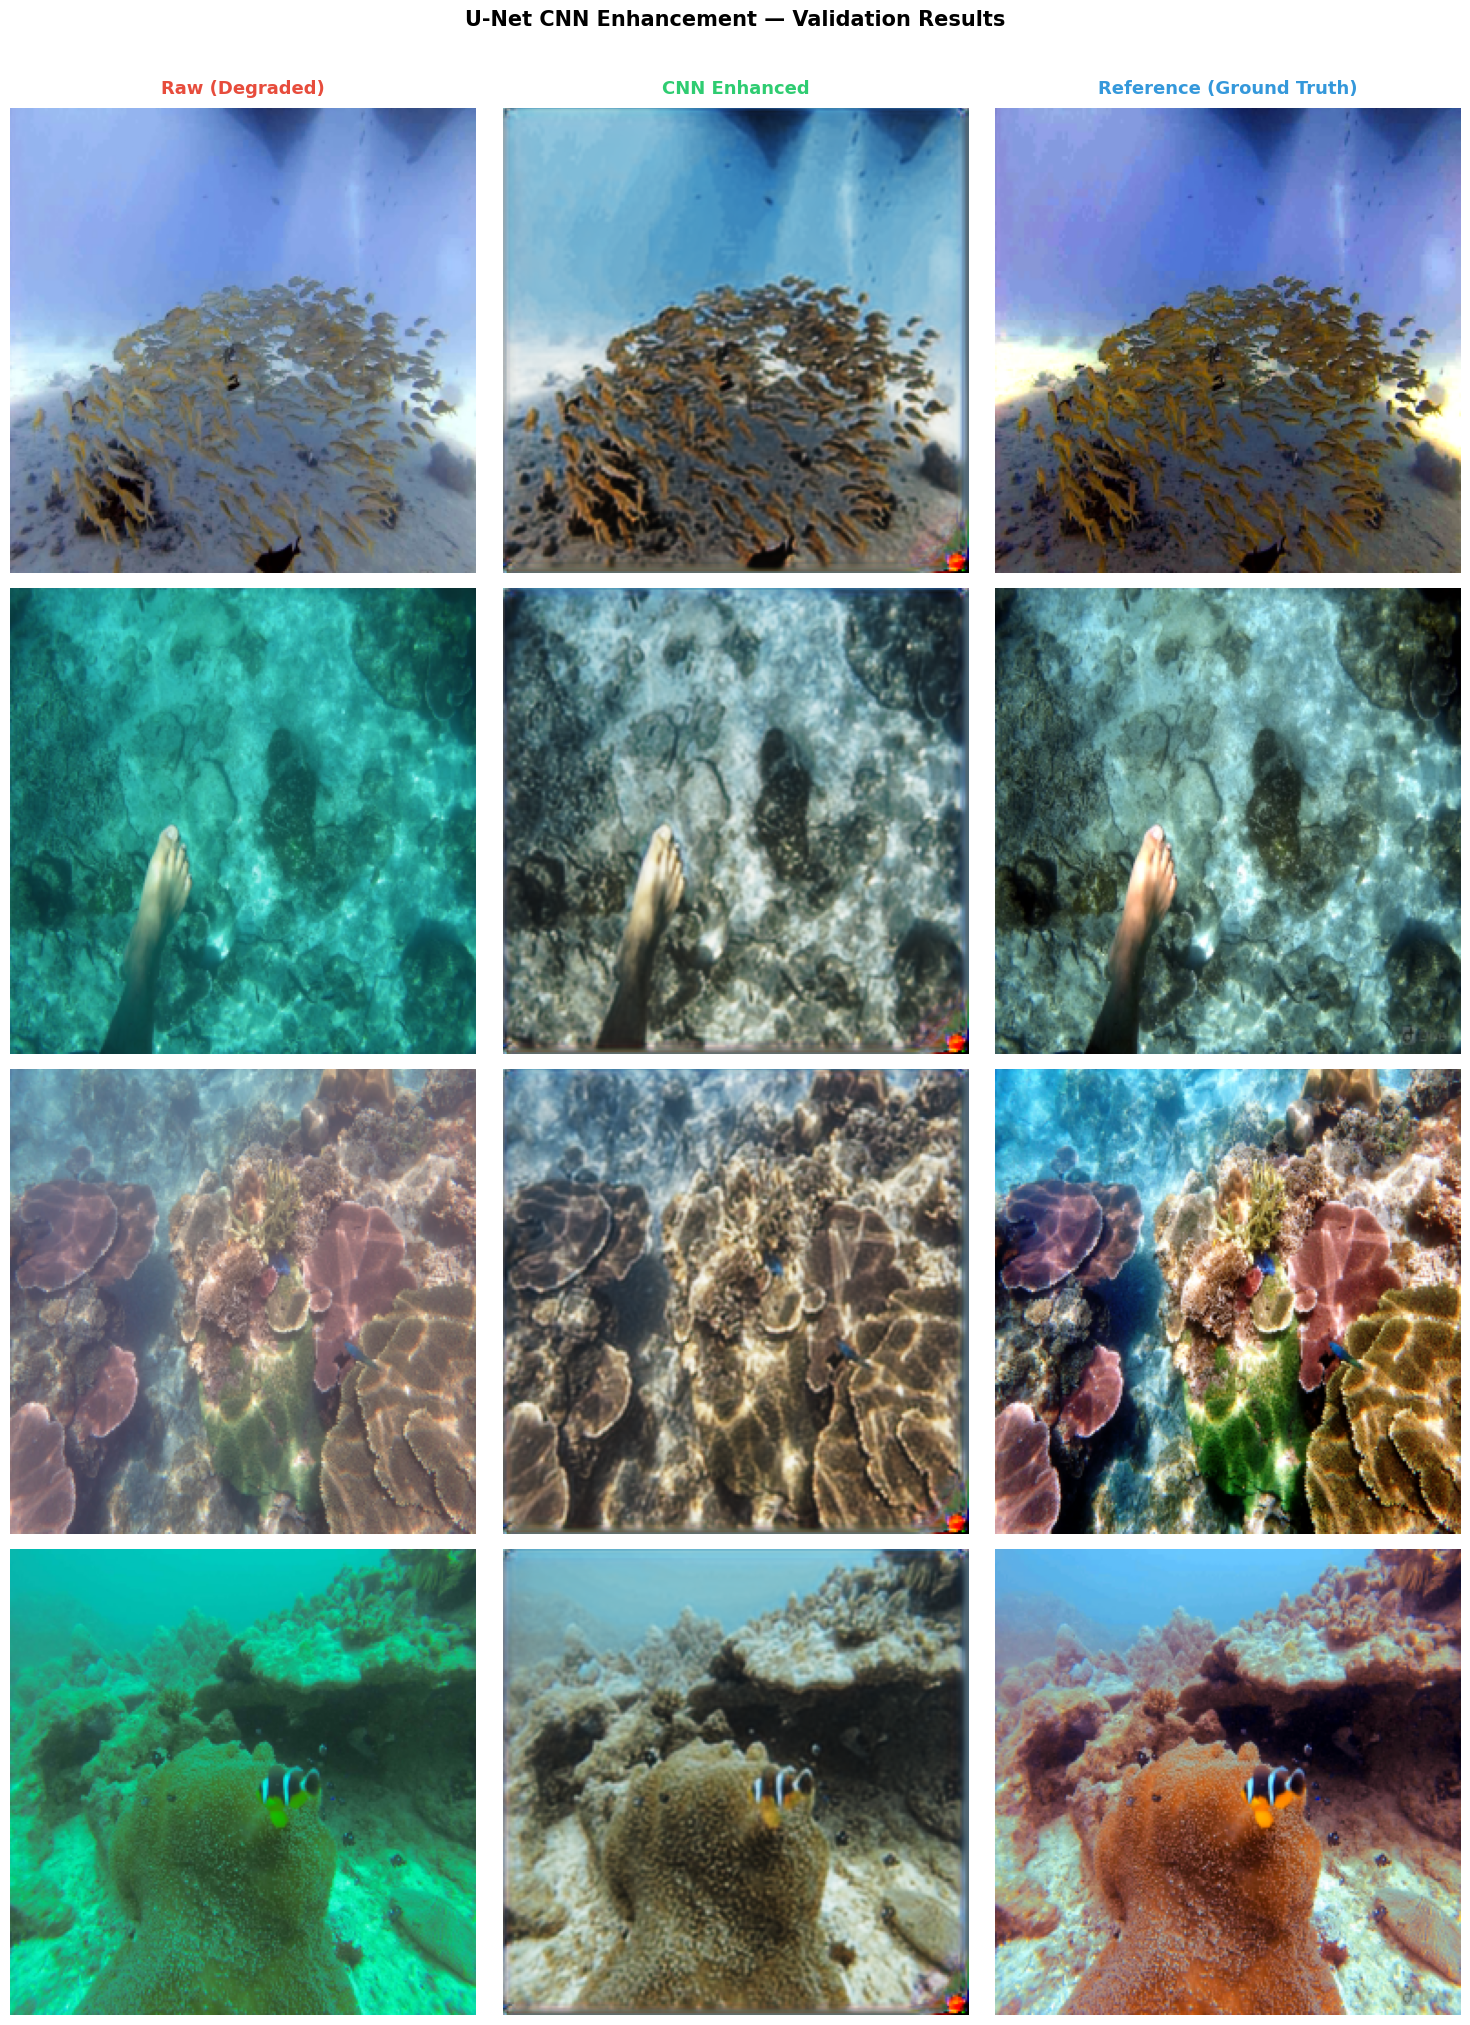

✅ Visual check complete
   Saved to Drive: /content/drive/MyDrive/underwater-data/cnn_samples.png


In [20]:
# ── Visual Results ────────────────────────────────────────────────────────────
# Runs 4 validation images through the trained model.
# Shows raw / CNN-enhanced / reference side by side.
# Includes per-sample PSNR and SSIM scores for each enhanced image.

import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

N_SAMPLES = 4

fig, axes = plt.subplots(N_SAMPLES, 3, figsize=(15, 5 * N_SAMPLES))
col_titles = ["Raw (Degraded)", "CNN Enhanced", "Reference (Ground Truth)"]
col_colours = ["#e74c3c", "#2ecc71", "#3498db"]

print("Running inference on validation samples...\n")

for row in range(N_SAMPLES):
    raw      = val_raw[row]
    ref      = val_ref[row]

    # Run image through model
    # np.newaxis adds a batch dimension: (256,256,3) → (1,256,256,3)
    enhanced = model.predict(raw[np.newaxis, ...], verbose=0)[0]

    # Clip to valid range just in case sigmoid produced edge values
    enhanced = np.clip(enhanced, 0.0, 1.0)

    # ── Compute metrics for this sample ──
    sample_psnr = psnr(ref, enhanced, data_range=1.0)
    sample_ssim = ssim(ref, enhanced, channel_axis=2, data_range=1.0)

    # Also compute baseline (raw vs ref) to show improvement
    base_psnr = psnr(ref, raw, data_range=1.0)
    base_ssim = ssim(ref, raw, channel_axis=2, data_range=1.0)

    print(f"  Sample {row + 1}:")
    print(f"    Baseline  — PSNR: {base_psnr:.2f} dB  | SSIM: {base_ssim:.4f}")
    print(f"    CNN       — PSNR: {sample_psnr:.2f} dB  | SSIM: {sample_ssim:.4f}")
    print(f"    Improvement — PSNR: {sample_psnr - base_psnr:+.2f} dB | SSIM: {sample_ssim - base_ssim:+.4f}\n")

    images = [raw, enhanced, ref]

    for col, (img, title, colour) in enumerate(
        zip(images, col_titles, col_colours)
    ):
        ax = axes[row, col]
        ax.imshow(np.clip(img, 0, 1))
        ax.axis("off")

        # Column headers on first row only
        if row == 0:
            ax.set_title(title, fontsize=13, fontweight="bold", color=colour, pad=10)

        # Add row label on left column
        if col == 0:
            ax.set_ylabel(f"Sample {row + 1}", fontsize=11, rotation=90, labelpad=10)

        # Add metric scores below enhanced image
        if col == 1:
            ax.set_xlabel(
                f"PSNR: {sample_psnr:.2f} dB  |  SSIM: {sample_ssim:.4f}",
                fontsize=10,
                color="#2ecc71",
                fontweight="bold",
                labelpad=6
            )

plt.suptitle(
    "U-Net CNN Enhancement — Validation Results",
    fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()

SAMPLES_PATH = "/content/drive/MyDrive/underwater-data/cnn_samples.png"
plt.savefig(SAMPLES_PATH, dpi=150, bbox_inches="tight")
plt.show()

print("✅ Visual check complete")
print(f"   Saved to Drive: {SAMPLES_PATH}")